<a href="https://colab.research.google.com/github/mohammadismail-blip/uni/blob/main/project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
#Name:Muhammad Ismail Roll#24F-Ai-012

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from google.colab import drive

drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

Mounted at /content/drive


In [15]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

print(df.head())
print(df.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [36]:
# missing values
print(df.isnull().sum())

# duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print(df.shape)


Age                                  0
Attrition                            0
DailyRate                            0
DistanceFromHome                     0
Education                            0
EnvironmentSatisfaction              0
HourlyRate                           0
JobInvolvement                       0
JobLevel                             0
JobSatisfaction                      0
MonthlyIncome                        0
MonthlyRate                          0
NumCompaniesWorked                   0
PercentSalaryHike                    0
PerformanceRating                    0
RelationshipSatisfaction             0
StockOptionLevel                     0
TotalWorkingYears                    0
TrainingTimesLastYear                0
WorkLifeBalance                      0
YearsAtCompany                       0
YearsInCurrentRole                   0
YearsSinceLastPromotion              0
YearsWithCurrManager                 0
BusinessTravel_Travel_Frequently     0
BusinessTravel_Travel_Rar

In [21]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [22]:
# Convert categorical columns into numerical columns
df = pd.get_dummies(df, drop_first=True)

print(df.head())
print(df.shape)

   Age  Attrition  DailyRate  DistanceFromHome  Education  \
0   41          1       1102                 1          2   
1   49          0        279                 8          1   
2   37          1       1373                 2          2   
3   33          0       1392                 3          4   
4   27          0        591                 2          1   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                        2          94               3         2   
1                        3          61               2         2   
2                        4          92               2         1   
3                        4          56               3         1   
4                        1          40               3         1   

   JobSatisfaction  ...  JobRole_Laboratory Technician  JobRole_Manager  \
0                4  ...                          False            False   
1                2  ...                          False            False   

In [23]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1470, 44)
Target: (1470,)


In [24]:
#Training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 44)
Testing data: (294, 44)


In [25]:
#Apply Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("F1 Score:",
      f1_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression
Accuracy: 0.8605442176870748
F1 Score: 0.4383561643835616

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [26]:
#Apply Dicison Tree
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

print("Decision Tree")
print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("F1 Score:",
      f1_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree
Accuracy: 0.8333333333333334
F1 Score: 0.24615384615384617

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.44      0.17      0.25        47

    accuracy                           0.83       294
   macro avg       0.65      0.56      0.58       294
weighted avg       0.79      0.83      0.80       294



In [27]:
#Apply Random Forest
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_forest = random_forest.predict(X_test)

print("Random Forest")
print("Accuracy:",
      accuracy_score(y_test, y_pred_forest))

print("F1 Score:",
      f1_score(y_test, y_pred_forest))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_forest))

Random Forest
Accuracy: 0.8333333333333334
F1 Score: 0.1694915254237288

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [28]:
#Compare All Three Models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest)
    ]
})

print(results)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.860544  0.438356
1        Decision Tree  0.833333  0.246154
2        Random Forest  0.833333  0.169492


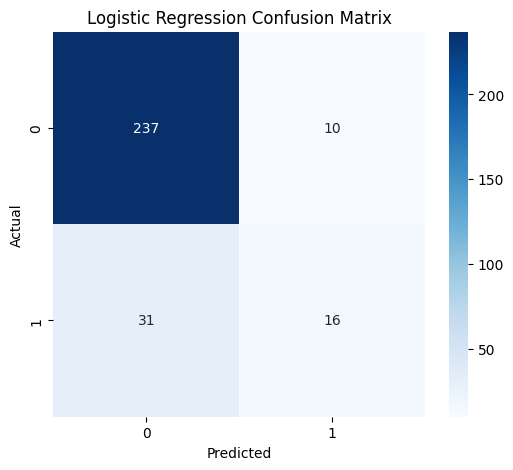

In [30]:
#Confusion Matrix
#Logistic Regression
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

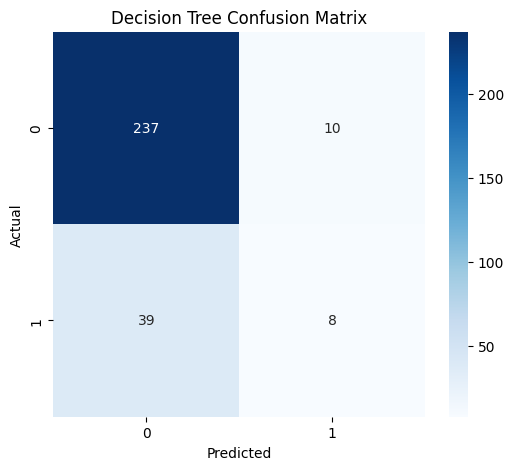

In [31]:
#Decision Tree
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

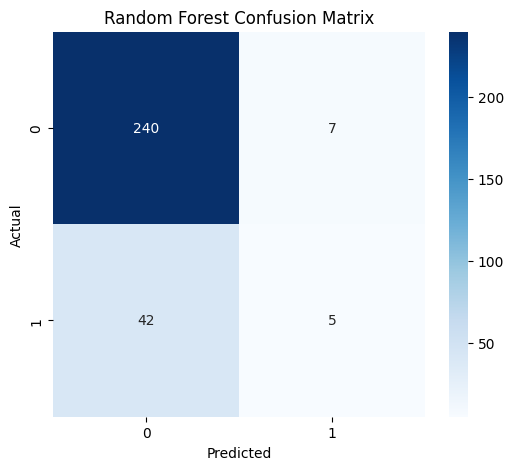

In [32]:
#Random Forest
cm = confusion_matrix(y_test, y_pred_forest)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Model Performance Comparison:
              Model  Accuracy (%)  F1 Score (%)
Logistic Regression     86.054422     43.835616
      Decision Tree     83.333333     24.615385
      Random Forest     83.333333     16.949153

BEST MODEL ACCORDING TO ACCURACY
Model: Logistic Regression
Accuracy: 86.05 %
F1 Score: 43.84 %


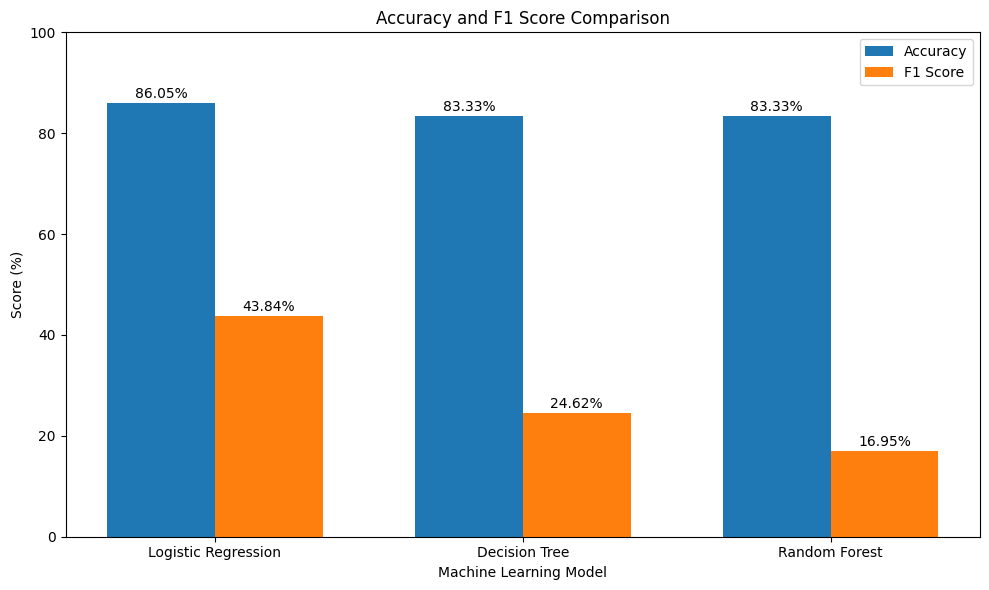

In [35]:
from sklearn.metrics import accuracy_score, f1_score

# Compare Accuracy and F1 Score

accuracy_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_logistic),
    "Decision Tree": accuracy_score(y_test, y_pred_tree),
    "Random Forest": accuracy_score(y_test, y_pred_forest)
}

f1_results = {
    "Logistic Regression": f1_score(y_test, y_pred_logistic),
    "Decision Tree": f1_score(y_test, y_pred_tree),
    "Random Forest": f1_score(y_test, y_pred_forest)
}


# Create DataFrame
comparison_df = pd.DataFrame({
    "Model": list(accuracy_results.keys()),
    "Accuracy": list(accuracy_results.values()),
    "F1 Score": list(f1_results.values())
})

# Convert Accuracy to percentage
comparison_df["Accuracy (%)"] = comparison_df["Accuracy"] * 100

# Convert F1 Score to percentage
comparison_df["F1 Score (%)"] = comparison_df["F1 Score"] * 100

# Comparison

print("Model Performance Comparison:")
print(
    comparison_df[
        ["Model", "Accuracy (%)", "F1 Score (%)"]
    ].to_string(index=False)
)


# Find Best Model According to Accuracy

best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("\n==============================")
print("BEST MODEL ACCORDING TO ACCURACY")
print("==============================")

print("Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy (%)"], 2), "%")
print("F1 Score:", round(best_model["F1 Score (%)"], 2), "%")

# Bar Graph

plt.figure(figsize=(10, 6))

x = range(len(comparison_df))
width = 0.35

plt.bar(
    [i - width/2 for i in x],
    comparison_df["Accuracy (%)"],
    width=width,
    label="Accuracy"
)

plt.bar(
    [i + width/2 for i in x],
    comparison_df["F1 Score (%)"],
    width=width,
    label="F1 Score"
)

plt.xticks(
    x,
    comparison_df["Model"]
)

plt.ylabel("Score (%)")
plt.xlabel("Machine Learning Model")
plt.title("Accuracy and F1 Score Comparison")

plt.ylim(0, 100)
plt.legend()


# Add values on bars
for i, value in enumerate(comparison_df["Accuracy (%)"]):
    plt.text(
        i - width/2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

for i, value in enumerate(comparison_df["F1 Score (%)"]):
    plt.text(
        i + width/2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()